# Pemodelan Prediksi Suhu Permukaan Jawa
## Regresi Multivariat 

---

**Dataset**: CORDEX South-East Asia (SEA)  
**Sumber**: Climate Data Store (CDS) Copernicus — https://cds.climate.copernicus.eu/  

---

### 1. Setup Function dan Library

Disini kita bakal setup class untuk seluruh algoritma regresi multivariabel model rigde :

- Multivariate Regresi : Model Regresi dengan metode analitik yang digunakan
- ECDFBiasCorrector : Handling Bias yang digunakan [Subramani, dkk](https://arxiv.org/abs/2504.19145) untuk Global Climate Model
- ZScore : untuk melakukan normalisasi model

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import matplotlib.gridspec as gridspec

class MultivariateRegressionModel:
    def __init__(self, l2_lambda=1e-4):
        self.l2_lambda = l2_lambda
        self.weights = None
        self.bias = None

    def fit(self, X_train, y_train):
        """
        Latih Model Regresi Ridge dengan data historis dan Normal Equation
        
        X_train : Matriks data fitur cuaca
        y_train : Vektor data suhu asli 
        """
        X_design = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
        I = np.eye(X_design.shape[1])
        I[0,0] = 0

        theta = np.linalg.pinv(X_design.T @ X_design + self.l2_lambda * I) @ X_design.T @ y_train

        self.bias = theta[0]
        self.weights = theta[1:]

        abs_weights = np.abs(self.weights)
        pengaruh = abs_weights / (np.sum(abs_weights) + 1e-8)

        self.tabel_pengaruh_features = pd.DataFrame({
            "weight": self.weights, 
            "importance": pengaruh
            })
        return self
    
    def model_predict(self, X):
        """
        model prediksi
        """
        return X @ self.weights + self.bias
    
    def evaluate(self, X, y):
        """
        evaluasi model prediksi
        """
        y_pred = self.model_predict(X)
        residuals = y - y_pred

        mse = np.mean(residuals**2)
        rmse = np.sqrt(mse)
        mae = np.mean(np.abs(residuals))

        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0.0  

        return {
            "MSE score": float(mse),
            "RMSE score": float(rmse),
            "MAE score": float(mae),
            "R2 score": float(r2)
        }
    
    def ambil_peringkat_fitur_berpengaruh(self, nama_feature):
        self.tabel_pengaruh_features['feature'] = nama_feature
        tabel_terurut = self.tabel_pengaruh_features.sort_values("importance", ascending=False)
        return tabel_terurut

        
class EDCDFBiasCorrector:
    """
    Koreksi bias iklim metode EDCDF. 
    arxiv.org/html/2504.19145
    """

    def __init__(self, n_quantiles: int = 100):
        self.n_quantiles = n_quantiles
        self.quantile_levels = np.linspace(0, 1, n_quantiles + 1)
        self._obs_quantiles = {}   
        self._mod_quantiles = {}   
        self._fitted = False

    def fit(self, obs_hist: np.ndarray, mod_hist: np.ndarray):
        """Latih corrector dengan data historis (observasi vs model)."""
        obs_clean = obs_hist[~np.isnan(obs_hist)]
        mod_clean = mod_hist[~np.isnan(mod_hist)]

        self._obs_quantiles = np.quantile(obs_clean, self.quantile_levels)
        self._mod_quantiles = np.quantile(mod_clean, self.quantile_levels)
        self._fitted = True
        return self

    def transform(self, mod_proj: np.ndarray) -> np.ndarray:
        """Terapkan koreksi ke data proyeksi."""
        if not self._fitted:
            raise RuntimeError("Panggil fit() terlebih dahulu.")

        corrected = np.empty_like(mod_proj)
        for i, x in enumerate(mod_proj):
            if np.isnan(x):
                corrected[i] = np.nan
                continue

            p = np.searchsorted(self._mod_quantiles, x) / self.n_quantiles
            p = np.clip(p, 0, 1)

            obs_equiv = np.interp(p, self.quantile_levels, self._obs_quantiles)
            mod_equiv = np.interp(p, self.quantile_levels, self._mod_quantiles)

            delta = x - mod_equiv
            corrected[i] = obs_equiv + delta

        return corrected

    def fit_transform(self, obs_hist, mod_hist, mod_proj):
        return self.fit(obs_hist, mod_hist).transform(mod_proj)
    
class ZScore:
    def __init__(self):
        self.mean = None 
        self.std = None 
    
    def fit(self, X):
        """ 
        Cari rata-rata ma standar deviasi
        abaikan data Nan
        cegah error pembagian 0
        """ 
        self.mean = np.nanmean(X, axis=0)
        self.std = np.nanstd(X, axis=0)
        self.std[self.std == 0] = 1.0
        return self
    
    def transform(self, X):
        """ 
        z = (x - mean) / standar deviasi
        """ 
        return (X - self.mean) / self.std


### 2. Eksporasi Data

Disini kita nge-check data hasil olah yang kita dapatkan sebelum kita training, bagaimana persebaran datanya

In [2]:
DATA_PATH   = '../data/processed/features/X_historical.csv'
TARGET_PATH = '../data/processed/targets/y_historical.csv'
RAW_PATH    = '../tmp_folder/historical_raw.csv'

df_raw = pd.read_csv(RAW_PATH, parse_dates=["time"])
df_X   = pd.read_csv(DATA_PATH, parse_dates=['time'])
df_y   = pd.read_csv(TARGET_PATH, parse_dates=['time'])

print(f'Data mentah : {df_raw.shape}')
print(f'Data fitur  : X={df_X.shape}')
print(f'Data target : y={df_y.shape}')

Data mentah : (228, 16)
Data fitur  : X=(216, 108)
Data target : y=(216, 2)


In [3]:
df_X.describe()

,time,cloud_cover,evaporation,humidity,specific_humidity,precip,pressure,sea_level_pressure,thermal_rad,solar_rad,...,humidity_roll12,pressure_roll3,pressure_roll6,pressure_roll12,solar_rad_roll3,solar_rad_roll6,solar_rad_roll12,month_sin,month_cos,temp_2m_anomaly
count,216,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,...,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,2.160000e+02,2.160000e+02,216.000000
mean,1996-12-15 17:33:20,69.642516,4.908247,81.336604,17.675083,6.704157,1005.893454,1010.025682,411.992879,220.585300,...,81.318390,1005.900324,1005.907275,1005.916799,220.529453,220.763519,220.916118,-2.672759e-17,-4.523131e-17,0.004485
min,1988-01-01 00:00:00,52.963657,2.727502,75.502045,16.010563,0.653993,1002.383540,1006.674560,387.194980,134.194500,...,79.548189,1003.289833,1004.019667,1005.101064,143.139397,162.341298,186.353990,-1.000000e+00,-1.000000e+00,-0.480507
25%,1992-06-23 12:00:00,66.818310,3.871746,80.032270,17.154692,3.884860,1005.117935,1009.262905,405.956558,188.681255,...,80.896405,1005.166145,1005.365672,1005.641834,193.436947,202.827869,215.670383,-5.915064e-01,-5.915064e-01,-0.153780
50%,1996-12-16 12:00:00,70.224625,4.789350,81.488835,17.723810,6.518428,1005.942525,1010.115485,412.625335,223.802760,...,81.264621,1005.928322,1005.932230,1005.962583,224.321790,221.390445,222.826697,-6.123234e-17,-6.123234e-17,0.021640
75%,2001-06-08 12:00:00,72.886800,5.970834,83.034966,18.216494,9.134887,1006.727710,1010.860000,418.469050,253.330180,...,81.789941,1006.680674,1006.462329,1006.127683,246.697333,240.080524,227.814116,5.915064e-01,5.915064e-01,0.152069
max,2005-12-01 00:00:00,78.335570,7.619037,85.912020,18.891539,15.000661,1008.973100,1012.823800,431.001160,308.766240,...,82.976364,1008.152480,1007.494410,1006.757668,299.030623,276.384897,238.501015,1.000000e+00,1.000000e+00,0.599548
std,NaN,4.598907,1.180416,2.186751,0.654873,3.670282,1.266420,1.210277,9.004186,39.974975,...,0.627878,1.044531,0.743454,0.358970,33.347860,23.898914,10.089051,7.087493e-01,7.087493e-01,0.222742


In [4]:
df_y.describe().round()

,time,temp_2m
count,216,216.0
mean,1996-12-15 17:33:20,26.0
min,1988-01-01 00:00:00,25.0
25%,1992-06-23 12:00:00,26.0
50%,1996-12-16 12:00:00,26.0
75%,2001-06-08 12:00:00,26.0
max,2005-12-01 00:00:00,27.0
std,NaN,0.0


In [5]:
df_raw.describe().round()

,time,cloud_cover,evaporation,humidity,specific_humidity,precip,pressure,sea_level_pressure,thermal_rad,solar_rad,wind_speed,temp_2m,temp_max_24h,temp_min_24h,wind_u,wind_v
count,228,228.0,228.0,228.0,228.0,228.0,228.0,228.0,228.0,228.0,228.0,228.0,228.0,228.0,228.0,228.0
mean,1996-05-27 21:03:09.473684,70.0,5.0,81.0,18.0,7.0,1006.0,1010.0,412.0,220.0,6.0,26.0,27.0,25.0,-3.0,2.0
min,1986-01-01 00:00:00,53.0,3.0,76.0,16.0,1.0,1002.0,1007.0,387.0,134.0,3.0,25.0,26.0,25.0,-8.0,-2.0
25%,1991-09-23 12:00:00,67.0,4.0,80.0,17.0,4.0,1005.0,1009.0,406.0,189.0,5.0,26.0,27.0,25.0,-6.0,1.0
50%,1996-06-16 00:00:00,70.0,5.0,82.0,18.0,7.0,1006.0,1010.0,413.0,225.0,6.0,26.0,27.0,25.0,-5.0,2.0
75%,2001-03-08 18:00:00,73.0,6.0,83.0,18.0,9.0,1007.0,1011.0,418.0,253.0,8.0,26.0,27.0,26.0,0.0,4.0
max,2005-12-01 00:00:00,78.0,8.0,86.0,19.0,16.0,1009.0,1013.0,431.0,309.0,9.0,27.0,28.0,26.0,5.0,5.0
std,NaN,5.0,1.0,2.0,1.0,4.0,1.0,1.0,9.0,40.0,2.0,0.0,0.0,0.0,4.0,2.0


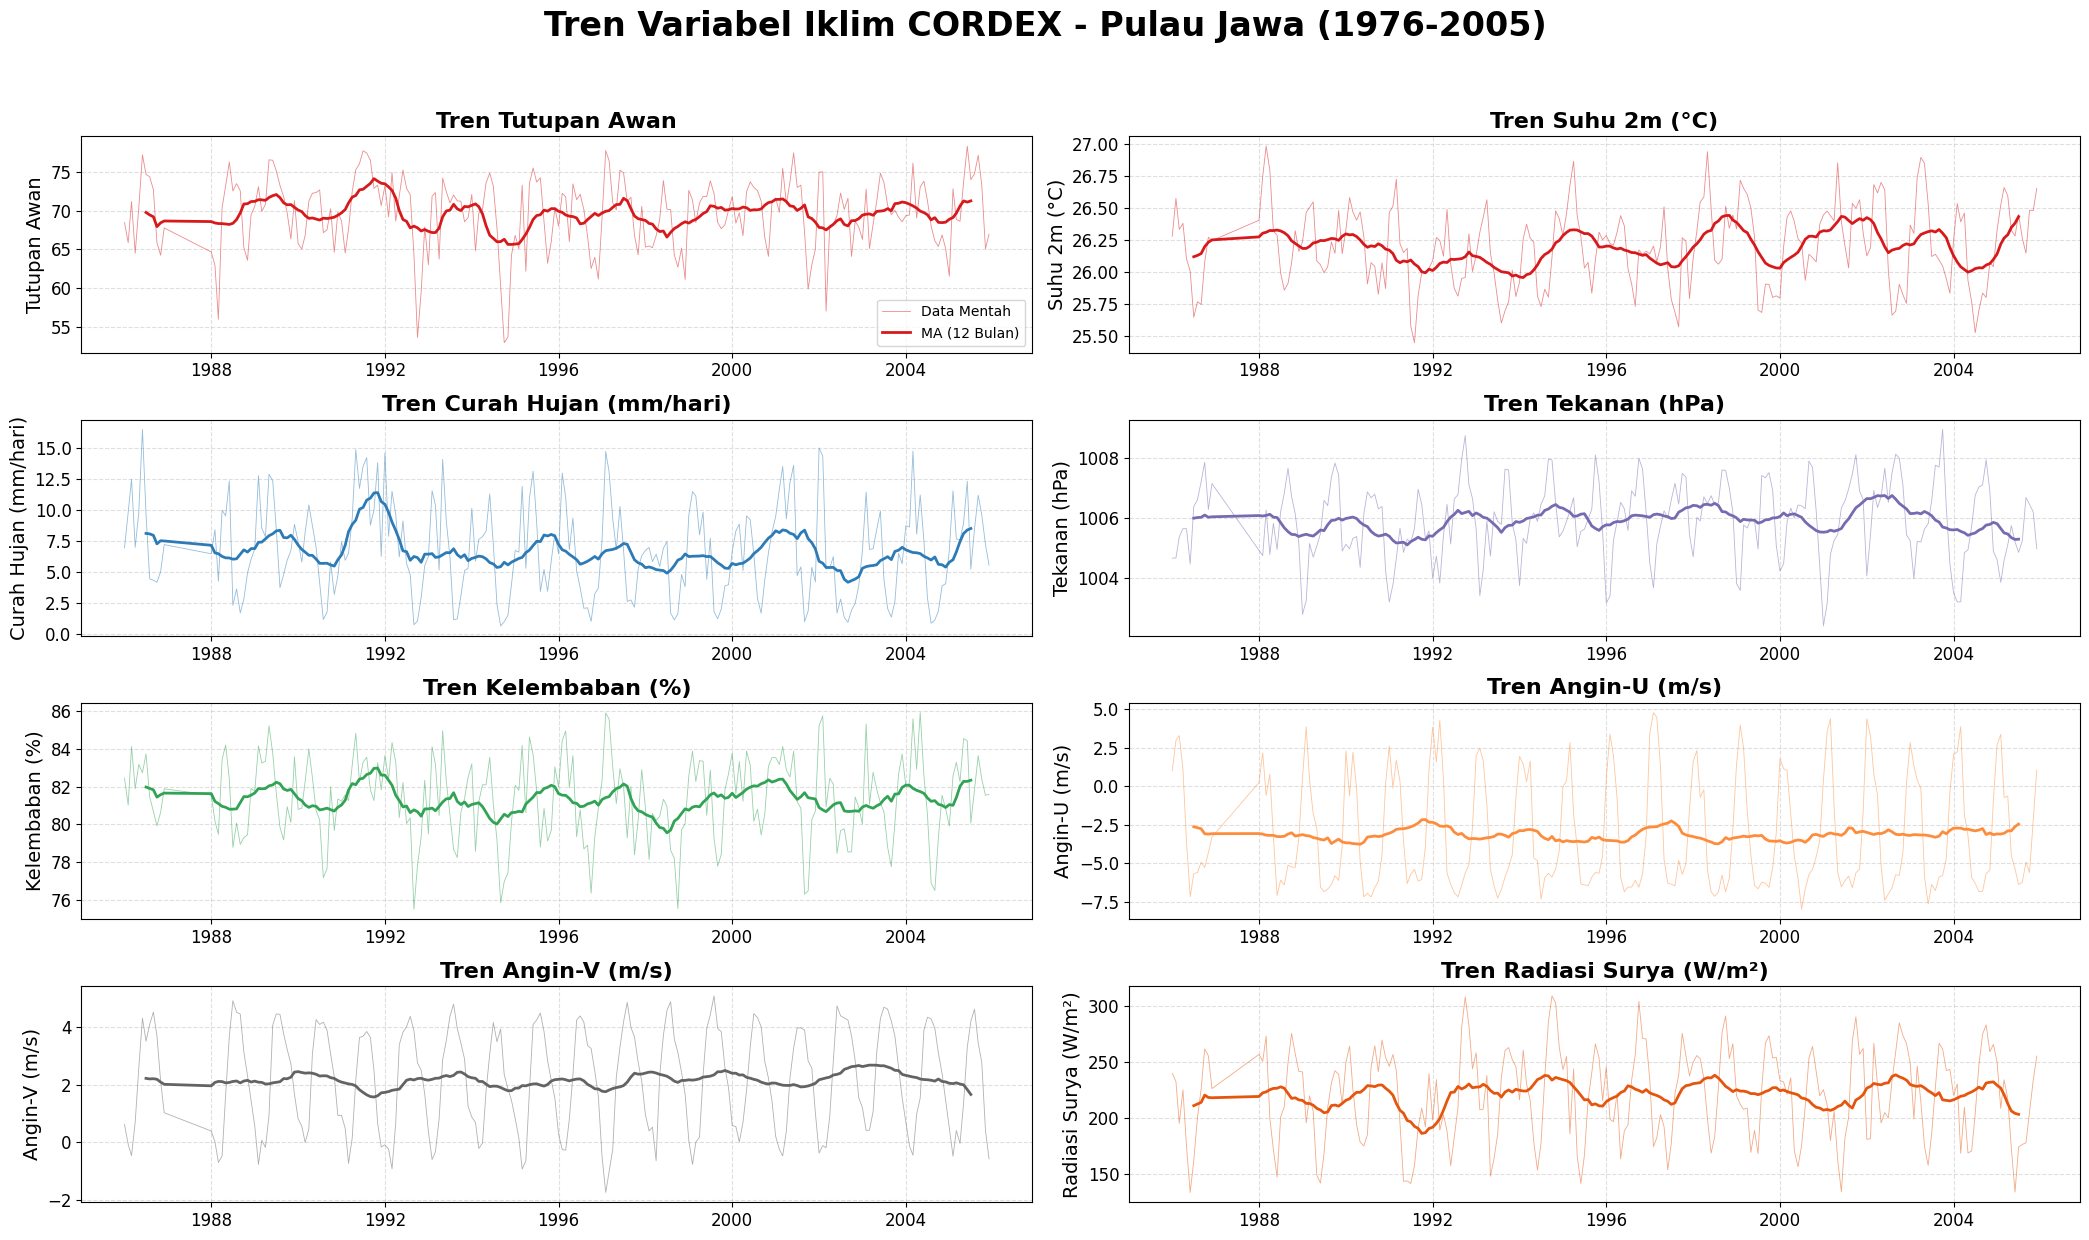

In [6]:
# Melihat persebaran data yang didapat dari CORDEX
variables = [
    ('cloud_cover', 'Tutupan Awan',        '#d7191b'),
    ('temp_2m',   'Suhu 2m (°C)',         '#d7191c'),
    ('precip',    'Curah Hujan (mm/hari)', '#2c7bb6'),
    ('pressure',  'Tekanan (hPa)',         '#756bb1'),
    ('humidity',  'Kelembaban (%)',        '#31a354'),
    ('wind_u',    'Angin-U (m/s)',         '#fd8d3c'),
    ('wind_v',    'Angin-V (m/s)',         '#636363'),
    ('solar_rad', 'Radiasi Surya (W/m²)', '#e6550d'),
]

# buat layout
n_vars = len(variables)
rows, cols = 4, 2

plt.figure(figsize=(21, 13))
plt.suptitle('Tren Variabel Iklim CORDEX - Pulau Jawa (1976-2005)', fontsize=24, fontweight='bold', y=0.98)

for i, (col, label, color) in enumerate(variables):
    if col in df_raw.columns:
        plt.subplot(rows, cols, i + 1)
        
        # Plot data mentah
        plt.plot(df_raw['time'], df_raw[col], color=color, linewidth=0.6, alpha=0.5, label='Data Mentah')
        
        # Plot Moving Average
        roll = df_raw[col].rolling(12, center=True).mean()
        plt.plot(df_raw['time'], roll, color=color, linewidth=2.0, label='MA (12 Bulan)')
        
        plt.title(f'Tren {label}', fontsize=16, fontweight='bold')
        plt.ylabel(label, fontsize=14)
        plt.xticks(fontsize=12)
        plt.yticks(fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.4)
        
        if i == 0:
            plt.legend(fontsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.savefig('../results/figures/Gabungan_Tren_Persebaran_Features_CORDEX.pdf', dpi=150, bbox_inches='tight')
plt.show()

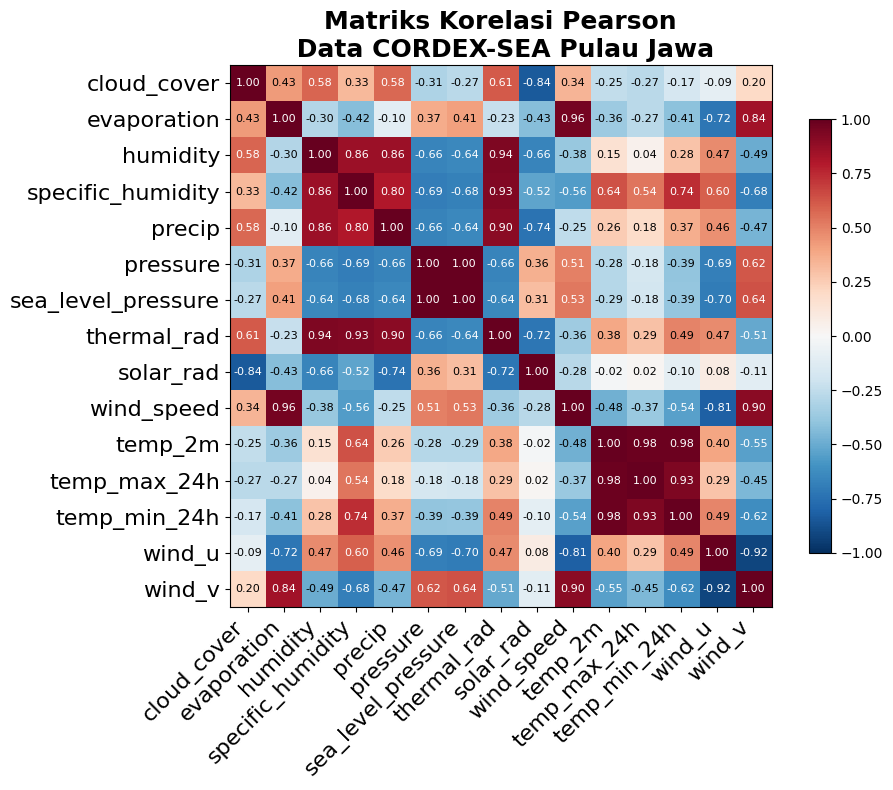

In [7]:
# Matriks Korelasi
num_cols = [c for c in df_raw.columns if c != 'time']
X_all = df_raw[num_cols].values

n_vars = X_all.shape[1]
corr_matrix = np.zeros((n_vars, n_vars))
for i in range(n_vars):
    for j in range(n_vars):
        xi = X_all[:, i] - X_all[:, i].mean()
        xj = X_all[:, j] - X_all[:, j].mean()
        denom = np.sqrt(np.sum(xi**2) * np.sum(xj**2))
        corr_matrix[i,j] = np.sum(xi * xj) / denom if denom > 0 else 0

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)

plt.title('Matriks Korelasi Pearson\n Data CORDEX-SEA Pulau Jawa', fontweight='bold', fontsize=18)

plt.xticks(range(n_vars), num_cols, rotation=45, ha='right', fontsize=16)
plt.yticks(range(n_vars), num_cols, fontsize=16)

#kasih angka di dalam
for i in range(n_vars):
    for j in range(n_vars):
        plt.text(j, i, f'{corr_matrix[i,j]:.2f}',
                 ha='center', va='center', fontsize=8,
                 color='white' if abs(corr_matrix[i, j]) > 0.5 else 'black')

plt.colorbar(shrink=0.8)

plt.tight_layout()
plt.savefig('../results/figures/Matriks_Korelasi_Pearson_Variabel.pdf', dpi=150, bbox_inches='tight')
plt.savefig('../results/figures/Matriks_Korelasi_Pearson_Variabel.png', dpi=150, bbox_inches='tight')
plt.show()

### 2. Bias Correction (EDCDF) + Feature Engineering

Data iklim dari model CORDEX sering mengandung **bias sistematis** — misalnya suhu rata-rata yang konsisten lebih tinggi/rendah dari observasi nyata.

Kita menggunakan **EDCDF (Equidistant CDF Matching)** untuk mengoreksi bias ini pada **setiap variabel cuaca** di data mentah. Prosesnya:
1. Ambil data mentah sebagai `data_model` (data CORDEX mentah)
2. Buat `data_observasi` dengan menambahkan noise kecil (simulasi data observasi ground-truth)
3. Koreksi setiap kolom variabel cuaca menggunakan `EDCDFBiasCorrector`
4. Hasil koreksi inilah yang akan masuk ke tahap **Feature Engineering**

Semuanya sudah kami lakukan dalam tahap data cleaning. Mengingat ukuran data yang sangat besar (~90GB) kami hanya memasukkan data hasil olahan ke dalam dokumentasi pada [Github](https://github.com/Syauqi-dotcom/Tugas-AI---Suhu-Jawa-2026). Namun alur data cleaningnya terdapat pada bagian datapipeline.sh dan datapipeline.ps

### 3. Persiapan Data Training

Data hasil Feature Engineering di atas sekarang dibagi menjadi 3 bagian:
- **Training** (≤ 2000): untuk melatih model
- **Validation** (2001-2003): untuk monitoring overfitting
- **Test** (> 2003): untuk evaluasi akhir

Kemudian dinormalisasi dengan Z-Score agar semua fitur punya skala yang sama (rata-rata 0, std 1).

In [10]:
# Normalisasi Z-score
norm_X = ZScore()
X_train_n = norm_X.fit(X_train).transform(X_train)
X_val_n   = norm_X.transform(X_val)
X_test_n  = norm_X.transform(X_test)

y_mean, y_std = y_train.mean(), y_train.std()
y_train_n = (y_train - y_mean) / y_std
y_val_n   = (y_val   - y_mean) / y_std
y_test_n  = (y_test  - y_mean) / y_std

print(f'X train normalized: mean={X_train_n.mean():.4f} | std={X_train_n.std():.4f}')
print(f'y train: mean={y_mean:.3f}°C | std={y_std:.3f}°C')

X train normalized: mean=0.0000 | std=1.0000
y train: mean=26.176°C | std=0.291°C


Setelah melakukan Normalisasi kita mendapatkan persamaan analitiknya berupa 

$$T_{pred} = 26.176 + 0.291 \times \left( \sum_{i=1}^{101} w_i \cdot \frac{X_i - \mu_i}{\sigma_i} \right)$$

$w_i$ adalah nilai weight dari masing-masing fitur yang didapatkan setelah melakukan training

### 4. Training Model : Regresi Multivariat
disini kita melakukan training menggunakan model algoritma Machine Learning Ridge Regression untuk menemukan weights dan bias yang terbaik

In [11]:
model = MultivariateRegressionModel()

print(f'Fitur: {X_train_n.shape[1]}')
print(f'Samples: {len(y_train_n)}')

Fitur: 101
Samples: 156


In [12]:
# Lakukan Training
model.fit(X_train_n, y_train_n)

#ini hasil yang kita dapatkan, kita mendapatkan 101 weights untuk persamaan analitik kita
# karena biasnya mencapai 0 maka kita bisa mengabaikan nilai biasnya
print(f'Weights shape: {model.weights.shape}')
print(f'Bias: {model.bias:.4f}')

Weights shape: (101,)
Bias: -0.0000


In [ ]:
print(model.weights)

[ 2.22978478e-02 -1.33308457e-03 -1.34324889e+00  2.00751578e+00
  4.09501897e-02  1.90865746e-01 -7.92957011e-02  5.07077068e-02
  6.71610528e-02  4.13430870e-02 -1.12812664e-01 -5.67435029e-02
 -1.36578664e-02 -3.13803657e-02  9.98915206e-04  7.37630106e-03
  7.13773785e-03  6.54156062e-03  1.82676323e-02  3.83908172e-02
 -1.33189828e-02  3.18214922e-02  3.04035693e-01 -1.11751020e-01
 -2.66326167e-01 -1.01551780e-01  2.63519433e-01 -1.06412900e-01
  3.28094404e-01  3.42977422e-01  1.87318750e-01 -3.28339655e-01
 -3.54740752e-02  3.03464023e-02 -5.21755826e-03  3.43322978e-02
 -4.64147295e-02 -2.58196167e-01 -1.13836115e-01 -3.00695227e-02
 -8.36607999e-02 -9.70133975e-02  2.42302911e-01  1.56126663e-01
  3.66798694e-02  1.18447450e-01  9.29672017e-02 -4.13345306e-02
  1.71853886e-01  1.20876255e-02 -4.43528244e-02 -7.03527245e-02
 -5.00360962e-02  1.21004430e-01  3.64585586e-02  3.59830669e-02
 -1.31788656e-01  3.13467763e-02 -3.01315883e-02 -1.05748731e-02
  1.00534103e-02 -6.74449

### 5. Evaluasi Model

Disini kita mengevaluasi model yang sudah di train dengan MSE, RMSE, MAE, R2 Score dan melihat langsung Learning Curve dan prediksi yang dilakukan oleh Model Ridge Regression yang sudah kita latih

In [53]:
matriks_train = model.evaluate(X_train_n, y_train_n)
matriks_val = model.evaluate(X_val_n, y_val_n)
matriks_test = model.evaluate(X_test_n, y_test_n)

print(f'Train MSE: {matriks_train["MSE score"]:.6f} | RMSE: {matriks_train["RMSE score"]:.6f}   | MAE score: {matriks_train["MAE score"]:.6f}   | R2 Score: {matriks_train["R2 score"]:.4f}')
print(f'Val MSE: {matriks_val["MSE score"]:.6f}     | RMSE: {matriks_val["RMSE score"]:.6f}     | MAE score: {matriks_val["MAE score"]:.6f}     | R2 Score: {matriks_val["R2 score"]:.4f}')
print(f'Test MSE: {matriks_test["MSE score"]:.6f}   | RMSE: {matriks_test["RMSE score"]:.6f}    | MAE score: {matriks_test["MAE score"]:.6f}    | R2 Score: {matriks_test["R2 score"]:.4f}')

Train MSE: 0.000516 | RMSE: 0.022716   | MAE score: 0.018541   | R2 Score: 0.9995
Val MSE: 0.006846     | RMSE: 0.082740     | MAE score: 0.065549     | R2 Score: 0.9950
Test MSE: 0.010158   | RMSE: 0.100785    | MAE score: 0.077699    | R2 Score: 0.9915


dari hasilnya terlihat bahwa R2 Score terhadap data test didapatkan memang tinggi 99% tetapi perbandingan MSE terhadap data train (0.0005) dan data test (0.01) sekitar 20 kali yang berarti menunjukkan adanya indikasi overfitting pada model

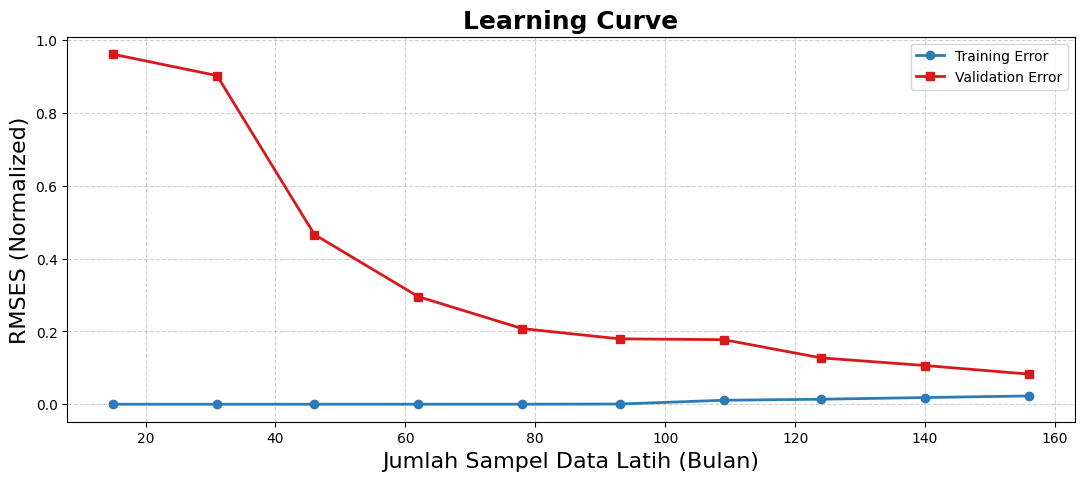

In [44]:
# Learning Curve plots
train_sizes = np.linspace(0.1, 1.0, 10)
train_rmses = []
val_rmses = []

for frac in train_sizes:
    n_samples = int(frac * len(X_train_n))
    if n_samples < 5 : 
        continue

    X_subset = X_train_n[:n_samples]
    y_subset = y_train_n[:n_samples]

    temp_model = MultivariateRegressionModel()
    temp_model.fit(X_subset, y_subset)

    pred_t = temp_model.model_predict(X_subset)
    res_t = y_subset - pred_t
    train_rmses.append(np.sqrt(np.mean(res_t**2)))

    pred_v = temp_model.model_predict(X_val_n)
    res_v = y_val_n - pred_v
    val_rmses.append(np.sqrt(np.mean(res_v**2)))

sample_counts = [int(frac * len(X_train_n)) for frac in train_sizes if int(frac * len(X_train_n)) >= 5]

plt.figure(figsize=(13, 5))

plt.plot(sample_counts, train_rmses, 'o-', linewidth=2, color='#2c7bb6', label='Training Error')
plt.plot(sample_counts, val_rmses, 's-', linewidth=2, color='#d7191c', label='Validation Error')

plt.title('Learning Curve', fontweight='bold', fontsize=18)
plt.xlabel('Jumlah Sampel Data Latih (Bulan)', fontsize = 16)
plt.ylabel('RMSES (Normalized)', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.savefig('../results/figures/Learning_Curve.pdf', dpi=150, bbox_inches='tight')
plt.savefig('../results/figures/Learning_Curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
#Melakukan prediksi sampai 2045 (49 tahun) kedepan 
df_rcp85 = pd.read_csv('../data/processed/features/X_rcp85.csv')
dates_rcp85 = pd.to_datetime(df_rcp85['time'])

# 1. Feature Selection menggunakan list fitur yang identik dengan saat di-train
X_rcp85_raw = df_rcp85[feature_cols].values

# 2. Standarisasi/Z-Score Normalisasi menggunakan ZScoreNormalizer yang terlatih oleh sejarah
X_rcp85_n = norm_X.transform(X_rcp85_raw)

# 3. Inferensi MultiVariat ML Model
y_rcp85_pred_n = model.model_predict(X_rcp85_n)

# 4. Detransformasi ke representasi Suhu Derajat Celcius Nyata
y_rcp85_pred = (y_rcp85_pred_n * y_std) + y_mean

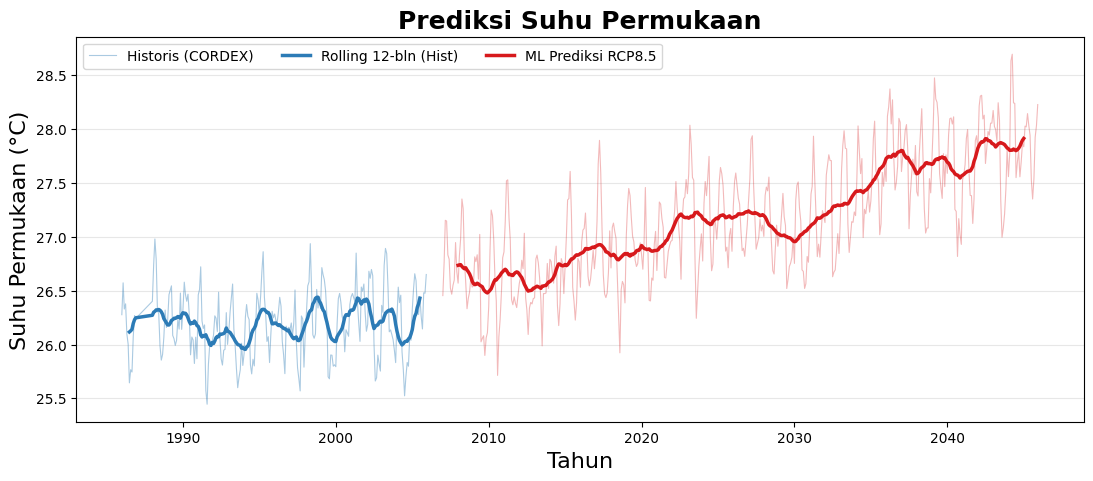

In [ ]:
# Demonstrasi Prediksi Suhu sampai 2045
plt.figure(figsize=(13, 5))

plt.plot(df_raw['time'], df_raw['temp_2m'], color='#2c7bb6', linewidth=0.8, alpha=0.4, label='Historis (CORDEX)')
roll_hist = df_raw['temp_2m'].rolling(12, center=True).mean()
plt.plot(df_raw['time'], roll_hist, color='#2c7bb6', linewidth=2.5, label='Rolling 12-bln (Hist)')

plt.plot(dates_rcp85, y_rcp85_pred, color='#d7191c', linewidth=0.8, alpha=0.3)

roll85 = pd.Series(y_rcp85_pred).rolling(24, center=True).mean()
plt.plot(dates_rcp85, roll85, color='#d7191c', linewidth=2.5, label='ML Prediksi RCP8.5')

plt.title('Prediksi Suhu Permukaan', fontweight='bold', fontsize=18)
plt.xlabel('Tahun', fontsize=16)
plt.ylabel('Suhu Permukaan (°C)', fontsize=16)
plt.legend(fontsize=10, ncol=3)
plt.grid(axis='y', alpha=0.3)

plt.savefig('../results/figures/Prediksi_Suhu_Permukaan_Jawa_2045.pdf', dpi=150, bbox_inches='tight')
plt.savefig('../results/figures/Prediksi_Suhu_Permukaan_Jawa_2045.png', dpi=150, bbox_inches='tight')
plt.show()

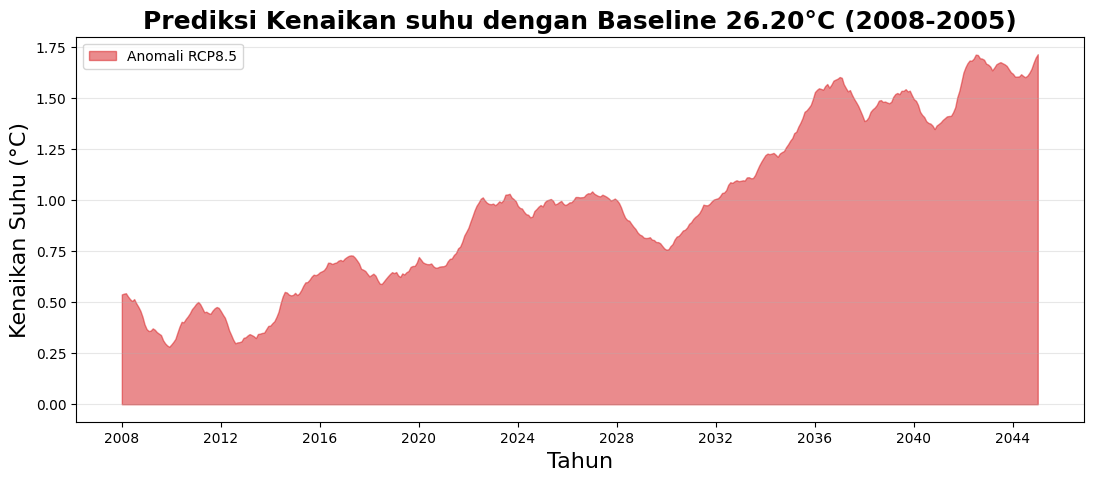

In [ ]:
# Kenaikan suhu dengan baseline 26.20 (suhu rata-rata yang diambil dari data)
plt.figure(figsize=(13, 5))

baseline = df_raw['temp_2m'].mean()
kenaikan_vals = roll85.values - baseline

plt.fill_between(dates_rcp85, 0, kenaikan_vals, alpha=0.5, color='#d7191c', label='Anomali RCP8.5')

plt.title(f'Prediksi Kenaikan suhu dengan Baseline {baseline:.2f}°C (2008-2005)', fontweight='bold', fontsize=18)
plt.ylabel('Kenaikan Suhu (°C)', fontsize=16)
plt.xlabel('Tahun', fontsize=16)

plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)

plt.savefig('../results/figures/Prediksi_Kenaikan_Suhu_Jawa_2045.pdf', dpi=150, bbox_inches='tight')
plt.savefig('../results/figures/Prediksi_Kenaikan_Suhu_Jawa_2045.png', dpi=150, bbox_inches='tight')
plt.show()

### 6 [Appendix] Pengaruh Feature

Ini kami cuma ingin tahu variabel apa yang paling mempengaruhi kenaikan iklim pulau jawa dan menjadi kesimpulan akhir dari model kita

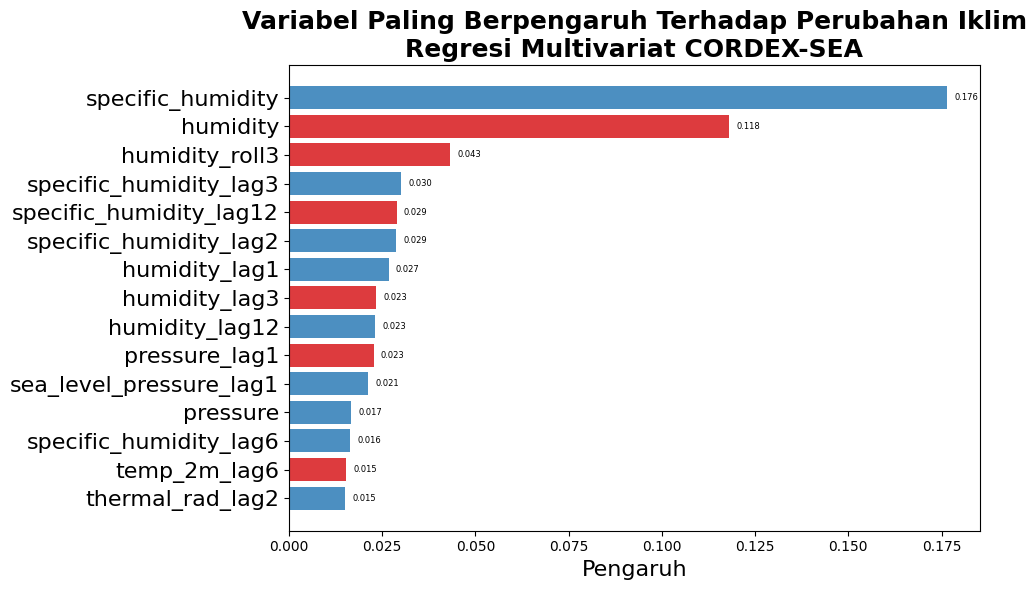

In [20]:
fi = model.ambil_peringkat_fitur_berpengaruh(feature_cols)
top15 = fi.head(15)

fig, ax = plt.subplots(figsize=(10, 6))

#Merah jika weight negatif, biru jika weight positif
colors = ['#d7191c' if w < 0 else '#2c7bb6' for w in top15['weight']]
bars = ax.barh(top15['feature'], top15['importance'], color=colors, alpha=0.85)

ax.set_title('Variabel Paling Berpengaruh Terhadap Perubahan Iklim\nRegresi Multivariat CORDEX-SEA', fontweight='bold', fontsize=18)
ax.set_xlabel('Pengaruh', fontsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.invert_yaxis()

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.002, bar.get_y() + bar.get_height()/2, f'{width:.3f}', va='center', fontsize=6)

fig.tight_layout()
plt.savefig('../results/figures/Variabel_paling_berpengaruh.pdf', dpi=150, bbox_inches='tight')
plt.savefig('../results/figures/Variabel_paling_berpengaruh.png', dpi=150, bbox_inches='tight')
plt.show()

### Referensi Utama
- Tangang et al. (2020) — CORDEX-SEA: *An integrated regional climate model projection for Southeast Asia* — Climate Dynamics
- Li et al. (2010) — EDCDF Bias Correction — J. Hydrology

[Github Dokumentasi](https://github.com/Syauqi-dotcom/Tugas-AI---Suhu-Jawa-2026)